## This is the code for generating Feature Heatmap plot.

By default, if you play this file directly, it will generate the Feature Heatmap plot with respect to our experiment result.

**Guideline**:  
Read in the Influence lists -> Compute the pairwise weighted Kendall tau matrix -> Turn the Matrix into the corresponding heatmap

**Format**:  
**Input** The Influence lists that you read in.  
**Output**  The Feature Heatmap Plot 

You don't need to change anything else if you only want to produce the Heatmap plot. You only need to change the read_csv part to the new data that you generated in the estimation code.

In [10]:
import pandas as pd
from scipy.stats import kendalltau,weightedtau
import numpy as np
import matplotlib.pyplot as plt
import dcor
import seaborn as sns

# Influence Ranking Read-In Area

Again, change here for your desired influence lists.

In [11]:
IF_1 = pd.read_csv("NumberOfFeatures0Padding/IF_Feature_Column_10_00_0padding.csv")
IF_2 = pd.read_csv("NumberOfFeatures0Padding/IF_Feature_Column_10_10_0padding.csv")
IF_3 = pd.read_csv("NumberOfFeatures0Padding/IF_Feature_Column_10_14_0padding.csv")
IF_4 = pd.read_csv("NumberOfFeatures0Padding/IF_Feature_Column_10_18_0padding.csv")
IF_5 = pd.read_csv("NumberOfFeatures0Padding/IF_Feature_Column_10_22_0padding.csv")
IF_6 = pd.read_csv("NumberOfFeatures0Padding/IF_Feature_Column_10_26_0padding.csv")
IF_7 = pd.read_csv("NumberOfFeatures0Padding/IF_Feature_Column_10_30_0padding.csv")
IF_8 = pd.read_csv("NumberOfFeatures0Padding/IF_Feature_Column_10_34_0padding.csv")
IF_9 = pd.read_csv("NumberOfFeatures0Padding/IF_Feature_Column_10_38_0padding.csv")
IF_10 = pd.read_csv("NumberOfFeatures0Padding/IF_Feature_Column_10_42_0padding.csv")

TC_1 = pd.read_csv("NumberOfFeatures0Padding/TC_Feature_Column_10_00_0padding.csv")
TC_2 = pd.read_csv("NumberOfFeatures0Padding/TC_Feature_Column_10_10_0padding.csv")
TC_3 = pd.read_csv("NumberOfFeatures0Padding/TC_Feature_Column_10_14_0padding.csv")
TC_4 = pd.read_csv("NumberOfFeatures0Padding/TC_Feature_Column_10_18_0padding.csv")
TC_5 = pd.read_csv("NumberOfFeatures0Padding/TC_Feature_Column_10_22_0padding.csv")
TC_6 = pd.read_csv("NumberOfFeatures0Padding/TC_Feature_Column_10_26_0padding.csv")
TC_7 = pd.read_csv("NumberOfFeatures0Padding/TC_Feature_Column_10_30_0padding.csv")
TC_8 = pd.read_csv("NumberOfFeatures0Padding/TC_Feature_Column_10_34_0padding.csv")
TC_9 = pd.read_csv("NumberOfFeatures0Padding/TC_Feature_Column_10_38_0padding.csv")
TC_10 = pd.read_csv("NumberOfFeatures0Padding/TC_Feature_Column_10_42_0padding.csv")

In [12]:
sorted_IF_lists = [IF_1, IF_2,IF_3,IF_4,IF_5,IF_6,IF_7,IF_8,IF_9,IF_10]
sorted_TC_lists = [TC_1, TC_2,TC_3,TC_4,TC_5,TC_6,TC_7,TC_8,TC_9,TC_10]
Train_Size = [10,20,24,28,32,36,40,44,48,52]

1. Here we initial the weighted kendall tau matrix.

In [13]:
num_lists = len(sorted_IF_lists)

In [14]:
tau_matrix_TC = np.full((num_lists, num_lists), np.nan)
tau_matrix_IF = np.full((num_lists, num_lists), np.nan)
print(tau_matrix_IF)

[[nan nan nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan nan nan]]


2. Here we compute the pairwise weighted kendall tau value for all the Influence Function's ranked influence lists.

In [15]:
for i in range(num_lists):
    tau_matrix_IF[i, i] = 1.0
    for j in range(i + 1, num_lists):
        df1 = sorted_IF_lists[i]
        df2 = sorted_IF_lists[j]
        max_abs1 = df1['Score'].abs().max()
        df1['Score'] = df1['Score'] / max_abs1    
        max_abs2 = df2['Score'].abs().max()
        df2['Score'] = df2['Score'] / max_abs2
        merged = pd.merge(df1, df2, on='Train_ID', how='inner')
        wt, _ = weightedtau(merged["Score_x"], merged["Score_y"],
                        weigher = lambda x: (np.abs(merged["Score_x"][x]) + np.abs(merged["Score_y"][x]))/2, rank = None)
        #wt, _ = kendalltau(merged["Score_x"], merged["Score_y"])
        tau_matrix_IF[i, j] = wt
        tau_matrix_IF[j, i] = wt

print(tau_matrix_IF)

[[1.         0.93635337 0.9176821  0.89811951 0.88951277 0.87468885
  0.86669105 0.85328433 0.85247347 0.84493146]
 [0.93635337 1.         0.97282014 0.95315437 0.94152002 0.92814301
  0.91928739 0.90703099 0.90463483 0.89683001]
 [0.9176821  0.97282014 1.         0.9744578  0.96307618 0.94895037
  0.93978106 0.92723627 0.92274422 0.91537644]
 [0.89811951 0.95315437 0.9744578  1.         0.98234469 0.9660418
  0.95770156 0.9460478  0.93937347 0.93245734]
 [0.88951277 0.94152002 0.96307618 0.98234469 1.         0.97506388
  0.96807593 0.95672227 0.94879129 0.94232939]
 [0.87468885 0.92814301 0.94895037 0.9660418  0.97506388 1.
  0.98196116 0.9699626  0.96218847 0.95402804]
 [0.86669105 0.91928739 0.93978106 0.95770156 0.96807593 0.98196116
  1.         0.98170742 0.9714756  0.96395434]
 [0.85328433 0.90703099 0.92723627 0.9460478  0.95672227 0.9699626
  0.98170742 1.         0.9803854  0.97486639]
 [0.85247347 0.90463483 0.92274422 0.93937347 0.94879129 0.96218847
  0.9714756  0.9803854

3. Here we compute the pairwise weighted kendall tau value for all the TracIn's ranked influence lists.

In [16]:
for i in range(num_lists):
    tau_matrix_TC[i, i] = 1.0
    for j in range(i + 1, num_lists):
        df1 = sorted_TC_lists[i]
        df2 = sorted_TC_lists[j]
        max_abs1 = df1['Score'].abs().max()
        df1['Score'] = df1['Score'] / max_abs1    
        max_abs2 = df2['Score'].abs().max()
        df2['Score'] = df2['Score'] / max_abs2
        merged = pd.merge(df1, df2, on='Train_ID', how='inner')
        wt, _ = weightedtau(merged["Score_x"], merged["Score_y"],
                         weigher = lambda x: (np.abs(merged["Score_x"][x]) + np.abs(merged["Score_y"][x]))/2, rank = None)
        #wt, _ = kendalltau(merged["Score_x"], merged["Score_y"])
        tau_matrix_TC[i, j] = wt
        tau_matrix_TC[j, i] = wt

print(tau_matrix_TC)

[[1.         0.98209912 0.97730092 0.97395409 0.97182867 0.96807942
  0.96502541 0.96202146 0.95985879 0.95839229]
 [0.98209912 1.         0.99291129 0.98768839 0.98476959 0.98110211
  0.9780555  0.97480074 0.97273907 0.97074701]
 [0.97730092 0.99291129 1.         0.99330439 0.98978616 0.9860762
  0.98307046 0.97982991 0.97760394 0.97550582]
 [0.97395409 0.98768839 0.99330439 1.         0.99523219 0.9903046
  0.98729251 0.98403084 0.98154875 0.97974396]
 [0.97182867 0.98476959 0.98978616 0.99523219 1.         0.99186523
  0.98923415 0.98625142 0.98360691 0.98215765]
 [0.96807942 0.98110211 0.9860762  0.9903046  0.99186523 1.
  0.9950526  0.99128473 0.98874323 0.9866522 ]
 [0.96502541 0.9780555  0.98307046 0.98729251 0.98923415 0.9950526
  1.         0.99533431 0.99236686 0.99013402]
 [0.96202146 0.97480074 0.97982991 0.98403084 0.98625142 0.99128473
  0.99533431 1.         0.99499997 0.99346622]
 [0.95985879 0.97273907 0.97760394 0.98154875 0.98360691 0.98874323
  0.99236686 0.99499997

4. Now we turn each weighted tau matrix into a triangular heatmap. This is to remove the duplicate half.

In [17]:
labels = [f"{size:}" for idx, size in enumerate(Train_Size)]
df_tau_IF = pd.DataFrame(tau_matrix_IF, index=labels, columns=labels)
df_tau_TC = pd.DataFrame(tau_matrix_TC, index=labels, columns=labels)

In [18]:
mask_lower = np.triu(np.ones_like(tau_matrix_IF, dtype=bool), k=1)
triangular_IF = tau_matrix_IF.copy()
triangular_IF[mask_lower] = np.nan
triangular_TC = tau_matrix_TC.copy()
triangular_TC[mask_lower] = np.nan

print(mask_lower)

[[False  True  True  True  True  True  True  True  True  True]
 [False False  True  True  True  True  True  True  True  True]
 [False False False  True  True  True  True  True  True  True]
 [False False False False  True  True  True  True  True  True]
 [False False False False False  True  True  True  True  True]
 [False False False False False False  True  True  True  True]
 [False False False False False False False  True  True  True]
 [False False False False False False False False  True  True]
 [False False False False False False False False False  True]
 [False False False False False False False False False False]]


IF

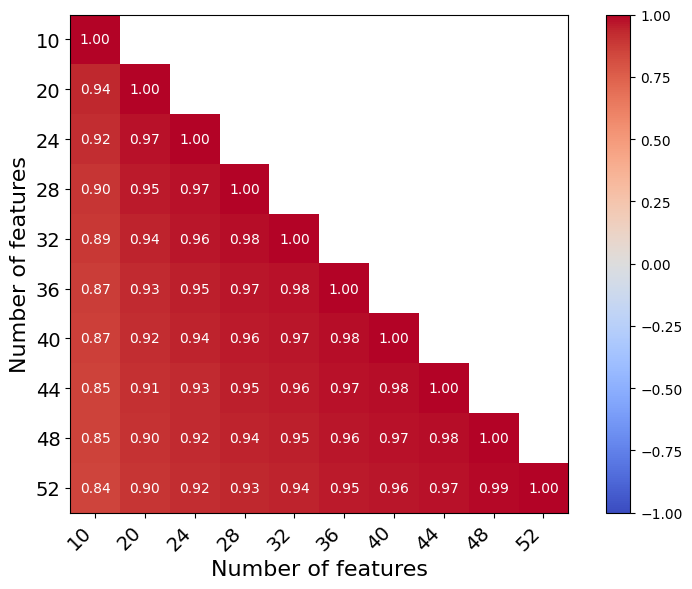

In [19]:
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(triangular_IF, interpolation="nearest", cmap="coolwarm", vmin=-1, vmax=1)
# ax.set_title("Pairwise Weighted Kendall Tau (IF lists)")
fig.colorbar(im, ax=ax)
ax.set_xticks(range(num_lists)); ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=14)
ax.set_yticks(range(num_lists)); ax.set_yticklabels(labels, fontsize=14)

rows, cols = np.where(~np.isnan(triangular_IF))
for i, j in zip(rows, cols):
    val = triangular_IF[i, j]
    txt_color = "white"
    ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=10, color=txt_color)
plt.xlabel("Number of features", fontsize=16)
plt.ylabel("Number of features", fontsize=16)
plt.tight_layout()

plt.savefig(
    "Feature_Heatmap_FOIF_0padding.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

TC

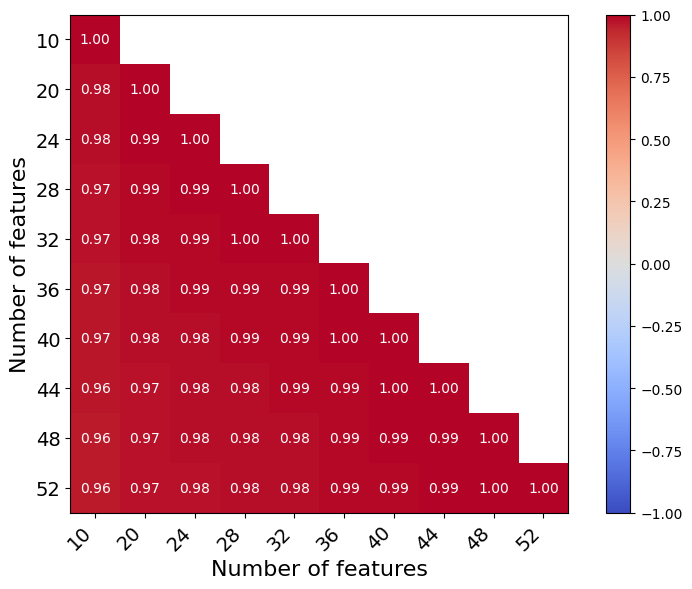

In [20]:
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(triangular_TC, interpolation="nearest", cmap="coolwarm", vmin=-1, vmax=1)
# ax.set_title("Pairwise Weighted Kendall Tau (TC lists)")
fig.colorbar(im, ax=ax)
ax.set_xticks(range(num_lists)); ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=14)
ax.set_yticks(range(num_lists)); ax.set_yticklabels(labels, fontsize=14)

rows, cols = np.where(~np.isnan(triangular_TC))
for i, j in zip(rows, cols):
    val = triangular_TC[i, j]
    txt_color = "white"
    ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=10, color=txt_color)
plt.xlabel("Number of features", fontsize=16)
plt.ylabel("Number of features", fontsize=16)
plt.tight_layout()

plt.savefig(
    "Feature_Heatmap_TC_0padding.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()